# UPI Fraud Detection — Random Forest Classifier


In [1]:
import sys
sys.path.append("../src")

import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import RocCurveDisplay

from models.evaluate import evaluate_model, print_report, print_summary, plot_confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_SEED = 42

X_train = pd.read_csv("../data/processed/X_train_final.csv")
y_train = pd.read_csv("../data/processed/y_train_final.csv")["is_fraud"]
X_test = pd.read_csv("../data/processed/X_test_final.csv")
y_test = pd.read_csv("../data/processed/y_test_final.csv")["is_fraud"]

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (220930, 61)  Test: (30000, 61)


## 1. Hyperparameter Tuning


In [2]:
param_dist = {
    "n_estimators": [100, 150, 200],
    "max_depth": [10, 15, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"],
}

search_sample = X_train.sample(frac=0.25, random_state=RANDOM_SEED)
y_search_sample = y_train.loc[search_sample.index]
print("Search subsample size:", search_sample.shape)

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1),
    param_distributions=param_dist, n_iter=8, cv=2,
    scoring="f1", random_state=RANDOM_SEED, n_jobs=-1, verbose=1,
)

t0 = time.time()
search.fit(search_sample, y_search_sample)
print(f"\nSearch completed in {time.time() - t0:.1f}s")
print("Best params:", search.best_params_)
print("Best CV F1 (on subsample):", round(search.best_score_, 4))

Search subsample size: (55232, 61)
Fitting 2 folds for each of 8 candidates, totalling 16 fits



Search completed in 84.1s
Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best CV F1 (on subsample): 0.9933


## 2. Refit Best Parameters on Full Training Set

In [3]:
t0 = time.time()
best_rf = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1, **search.best_params_)
best_rf.fit(X_train, y_train)
print(f"Full-data fit completed in {time.time() - t0:.1f}s")

Full-data fit completed in 70.3s


## 3. Evaluation on Test Set

In [4]:
y_pred = best_rf.predict(X_test)
print_report(y_test, y_pred, "Random Forest (tuned)")

rf_metrics = evaluate_model(best_rf, X_test, y_test, model_name="RandomForest", save=True)
print_summary(rf_metrics)

=== Random Forest (tuned) — Classification Report ===
              precision    recall  f1-score   support

    No Fraud       1.00      1.00      1.00     27616
       Fraud       0.95      0.97      0.96      2384

    accuracy                           0.99     30000
   macro avg       0.97      0.98      0.98     30000
weighted avg       0.99      0.99      0.99     30000



Model: RandomForest
  Accuracy:  0.9939
  Precision: 0.9508
  Recall:    0.9732
  F1 Score:  0.9619
  ROC-AUC:   0.9990


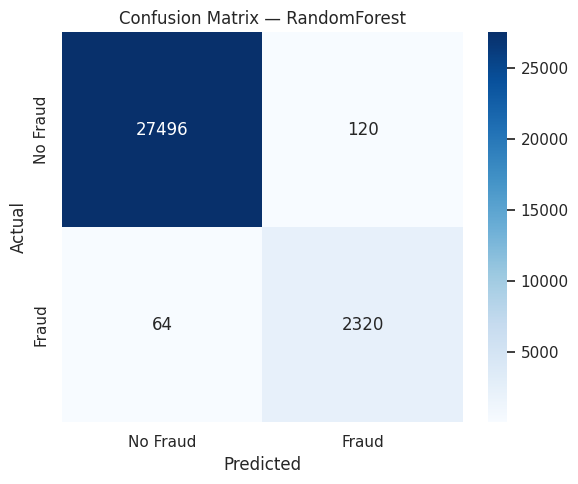

In [5]:
fig, ax = plot_confusion_matrix(rf_metrics, save_path="../reports/figures/20_rf_confusion_matrix.png")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


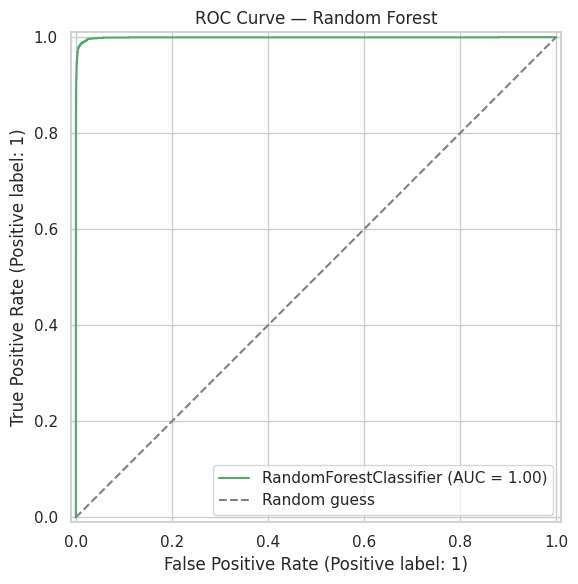

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_estimator(best_rf, X_test, y_test, ax=ax, color="#55A868")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_title("ROC Curve — Random Forest")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/21_rf_roc_curve.png", dpi=150)
plt.show()

## 4. Feature Importance


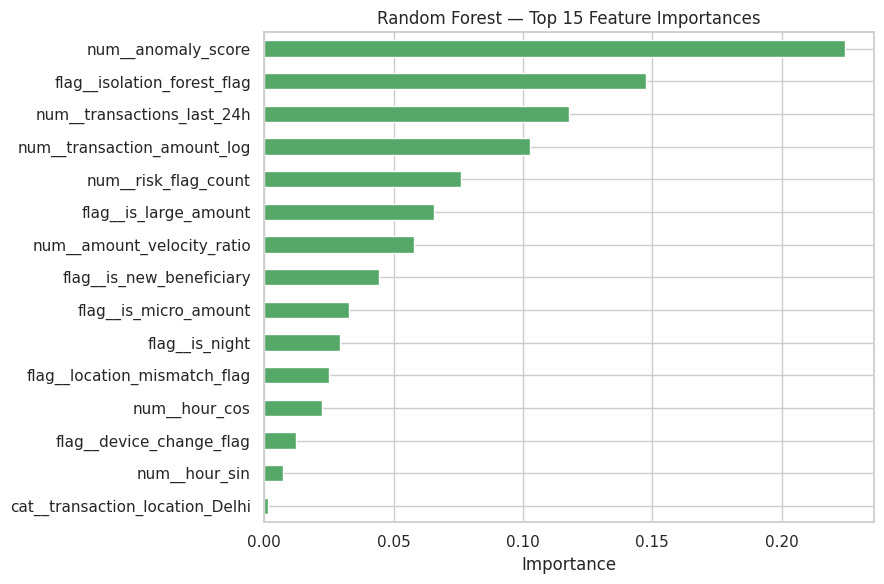

In [7]:
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
top_features.sort_values().plot(kind="barh", color="#55A868", ax=ax)
ax.set_title("Random Forest — Top 15 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("../reports/figures/22_rf_feature_importance.png", dpi=150)
plt.show()

## 5. Decision Tree vs Random Forest — Feature Importance Comparison


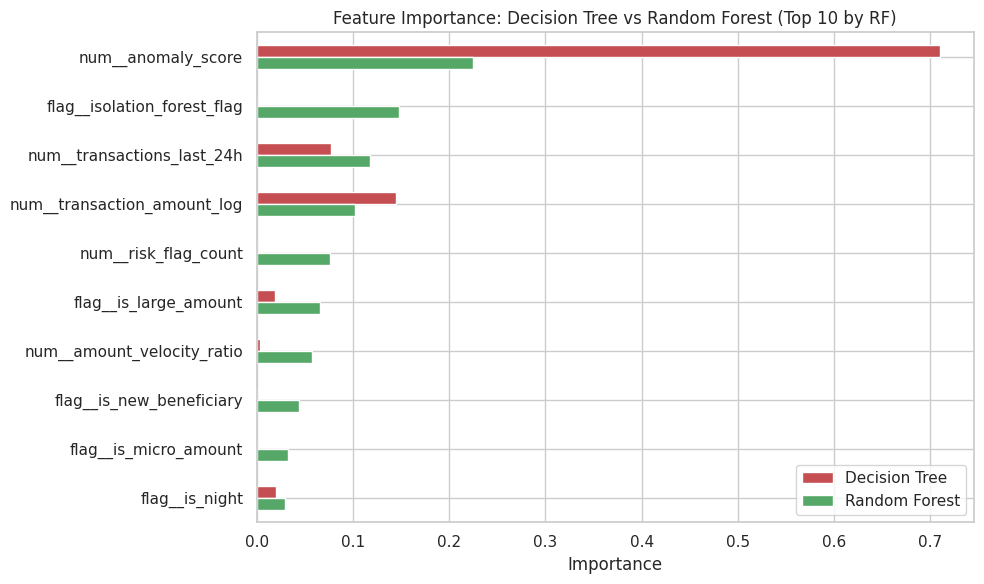

In [8]:
dt_model = joblib.load("../models/decision_tree.pkl")
dt_importances = pd.Series(dt_model.feature_importances_, index=X_train.columns)

compare_df = pd.DataFrame({
    "Decision Tree": dt_importances,
    "Random Forest": importances,
}).sort_values("Random Forest", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
compare_df.plot(kind="barh", ax=ax, color=["#C44E52", "#55A868"])
ax.set_title("Feature Importance: Decision Tree vs Random Forest (Top 10 by RF)")
ax.set_xlabel("Importance")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/figures/23_dt_vs_rf_importance.png", dpi=150)
plt.show()

## 6. Save Model

In [9]:
import os
os.makedirs("../models", exist_ok=True)
joblib.dump(best_rf, "../models/random_forest.pkl")
print("Saved to models/random_forest.pkl")

Saved to models/random_forest.pkl
